### Importing Libraries and Setting Up the EDA Environment
This cell imports the analysis and visualization libraries used throughout the notebook. Establishing a consistent plotting style is important for EDA because it makes traffic patterns easier to compare across multiple attack classes.

Key observations:
- `pandas` and `numpy` support large-scale flow analysis efficiently.
- `matplotlib` and `seaborn` help expose traffic behavior visually rather than only numerically.
- A shared plotting theme makes comparisons between benign and malicious traffic easier to interpret.


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="pastel")
plt.rcParams["figure.figsize"] = (8,5)

### Loading the Network Traffic Datasets
This step reads the benign and attack CSV files into memory. Loading all traffic categories together is necessary for comparative EDA because we want to observe how different attacks deviate from normal network behavior.

Key observations:
- The notebook includes benign traffic, UDP flood traffic, TCP flood traffic, and reconnaissance traffic.
- These categories represent distinct security scenarios with different packet and flow characteristics.


In [16]:
benign = pd.read_csv("data/Benign Traffic.csv")
ddos = pd.read_csv("data/DDoS UDP Flood.csv")
dos_tcp = pd.read_csv("data/DoS TCP Flood.csv", nrows=100000)  # limit size
recon = pd.read_csv("data/Recon Port Scan.csv")

print("Loaded all datasets")

Loaded all datasets


### Assigning Traffic Labels to Each Dataset
This cell adds readable class names to each subset before concatenation. Explicit labels are essential for EDA because every statistic and plot needs to relate traffic measurements back to the underlying network behavior.

Key observations:
- `BENIGN` represents normal background communication.
- `DDOS_UDP`, `DOS_TCP`, and `RECON` capture different malicious strategies.
- Clear labels make it possible to compare packet rate, duration, and throughput by traffic type.


In [17]:
benign["Label"] = "BENIGN"
ddos["Label"] = "DDOS_UDP"
dos_tcp["Label"] = "DOS_TCP"
recon["Label"] = "RECON"

### Combining All Traffic Sources into a Unified DataFrame
This step merges the labeled datasets into one table for joint analysis. Combining flows into a single DataFrame allows us to compute cross-class statistics and visualize attack behavior under a shared schema.

Key observations:
- A unified table is the foundation for class-wise profiling and plotting.
- The merged dataset supports direct comparison of normal and malicious flows.
- This structure is especially useful in network analysis where the same features must be interpreted across multiple attack classes.


In [18]:
df = pd.concat([benign, ddos, dos_tcp, recon], ignore_index=True)

print("Combined dataset shape:", df.shape)
df.head()

Combined dataset shape: (620718, 85)


,Flow ID,Src IP,Src Port,Dst IP,Dst Port,Protocol,Timestamp,Flow Duration,Total Fwd Packet,Total Bwd packets,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Attack Name,Label
0,34.173.20.6-192.168.137.234-443-58644-6,34.173.20.6,443,192.168.137.234,58644,6,14/09/2023 09:24:26 AM,14746364,6,0,...,0.0,0.0,0.0,0.0,14681116.0,0.000000,14681116.0,14681116.0,Benign Traffic,BENIGN
1,34.173.20.6-192.168.137.234-443-58646-6,34.173.20.6,443,192.168.137.234,58646,6,14/09/2023 09:24:41 AM,60102110,18,0,...,219123.0,0.0,219123.0,219123.0,14957706.0,190543.248665,15061923.0,14672051.0,Benign Traffic,BENIGN
2,52.40.210.103-192.168.137.40-18665-60378-6,52.40.210.103,18665,192.168.137.40,60378,6,14/09/2023 09:24:14 AM,90106769,9,0,...,582529.0,0.0,582529.0,582529.0,29841412.0,319090.538141,30049066.0,29473997.0,Benign Traffic,BENIGN
3,10.0.0.3-10.0.0.254-44505-1883-6,10.0.0.3,44505,10.0.0.254,1883,6,14/09/2023 09:24:15 AM,119998980,123,123,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,Benign Traffic,BENIGN
4,10.0.0.7-10.0.0.254-45727-1883-6,10.0.0.7,45727,10.0.0.254,1883,6,14/09/2023 09:24:15 AM,119998539,123,123,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,Benign Traffic,BENIGN


### Inspecting Dataset Structure and Data Types
This cell checks column names, data types, and non-null counts. Structural inspection is an important EDA step because network datasets often contain mixed data types, high-dimensional features, and fields that may need cleaning before modeling.

Key observations:
- `info()` helps verify that flow-level features loaded correctly.
- It highlights the overall dimensionality of the traffic dataset.
- It also reveals whether some networking features are incomplete or sparsely populated.


In [19]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 620718 entries, 0 to 620717
Data columns (total 85 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Flow ID                     620718 non-null  str    
 1   Src IP                      620718 non-null  str    
 2   Src Port                    620718 non-null  int64  
 3   Dst IP                      620718 non-null  str    
 4   Dst Port                    620718 non-null  int64  
 5   Protocol                    620718 non-null  int64  
 6   Timestamp                   620718 non-null  str    
 7   Flow Duration               620718 non-null  int64  
 8   Total Fwd Packet            620718 non-null  int64  
 9   Total Bwd packets           620718 non-null  int64  
 10  Total Length of Fwd Packet  620718 non-null  float64
 11  Total Length of Bwd Packet  620718 non-null  float64
 12  Fwd Packet Length Max       620718 non-null  float64
 13  Fwd Packet Length Min    

### Measuring Missing Values Across Features
This step identifies the columns with the most missing values. In traffic analysis, missingness can result from capture limitations, unsupported protocol fields, or attack flows that do not produce normal bidirectional exchanges.

Key observations:
- Missing-value inspection helps determine which features are reliable for comparison.
- Sparse features can distort descriptive statistics and visual summaries.
- This is especially relevant when comparing benign sessions with incomplete attack flows.


In [20]:
df.isnull().sum().sort_values(ascending=False).head(10)

Flow ID                 0
URG Flag Count          0
Fwd Packet/Bulk Avg     0
Fwd Bytes/Bulk Avg      0
Bwd Segment Size Avg    0
Fwd Segment Size Avg    0
Average Packet Size     0
Down/Up Ratio           0
ECE Flag Count          0
CWR Flag Count          0
dtype: int64

### Dropping Non-Analytical Identifier Columns
This cell removes fields such as IDs, IP addresses, and timestamps that are not the focus of this EDA. For exploratory profiling, keeping the analysis centered on behavioral flow features is more useful than relying on identifiers that may leak scenario-specific information.

Key observations:
- IP addresses and flow IDs are identifiers, not behavioral indicators.
- Removing them makes the analysis focus on traffic dynamics such as duration and rates.
- This also helps reduce noise before correlation analysis and dimensionality reduction.


In [21]:
drop_cols = ["Flow ID", "Source IP", "Destination IP", "Timestamp"]

df = df.drop(columns=[col for col in drop_cols if col in df.columns])

### Visualizing the Class Distribution
This cell counts how many flows belong to each traffic class and displays them in a bar chart. Class balance matters in EDA because some attack scenarios generate many short flows, while others generate fewer but more intense traffic bursts.

Key observations:
- Class counts provide context for interpreting all later plots.
- Large differences in flow volume can reflect how each attack manifests on the network.
- Reconnaissance and denial-of-service traffic often differ in both count and intensity.


Label
RECON       485522
DOS_TCP     100000
BENIGN       32620
DDOS_UDP      2576
Name: count, dtype: int64


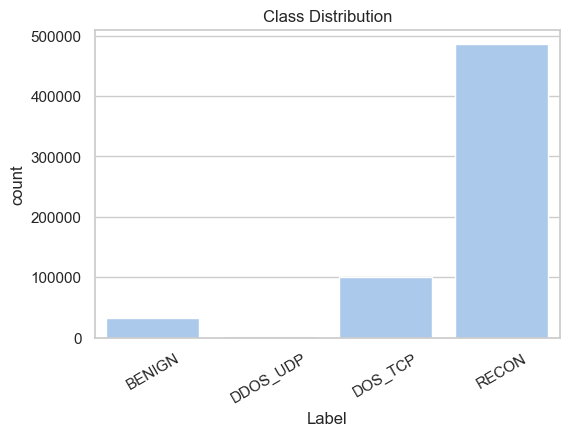

In [22]:
print(df["Label"].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x=df["Label"])
plt.title("Class Distribution")
plt.xticks(rotation=30)
plt.show()

### Interpreting the Class Distribution Plot
The class distribution highlights how the dataset is composed across benign and malicious categories. A larger number of `DOS_TCP` or `RECON` flows would suggest that these attacks generate many repeated connection attempts, while smaller `DDOS_UDP` counts do not necessarily imply lower severity because volumetric floods can be intense even with fewer sampled flows.

Key observations:
- High flow counts in scan or TCP flood traffic are consistent with repeated probing or connection-oriented attack behavior.
- Benign traffic typically appears as a smaller, more diverse baseline rather than a dominant single pattern.
- Raw counts should be interpreted alongside rate and duration features, not in isolation.


### Selecting Core Features for Comparative Analysis
This step defines a focused subset of traffic features for plotting. Choosing key flow metrics helps keep the EDA interpretable while still capturing the main network behaviors related to flooding, scanning, and normal communication.

Key observations:
- The selected features emphasize duration, packet counts, and throughput.
- These are directly tied to how aggressively traffic uses network resources.
- Restricting to available columns keeps the notebook robust across dataset variations.


In [23]:
features = [
    "Flow Duration",
    "Total Fwd Packets",
    "Total Backward Packets",
    "Flow Bytes/s",
    "Flow Packets/s"
]

features = [f for f in features if f in df.columns]

### Comparing Feature Distributions with Boxplots
This cell generates boxplots for the selected core features by class. Boxplots are valuable in network EDA because they show medians, spread, and outliers, which often reveal bursty or abnormal traffic behavior.

Key observations:
- Medians help compare the baseline behavior of benign and attack traffic.
- Wide spreads and extreme outliers can indicate unstable or flood-like patterns.
- Class-wise boxplots are especially useful for identifying how attacks distort normal flow statistics.


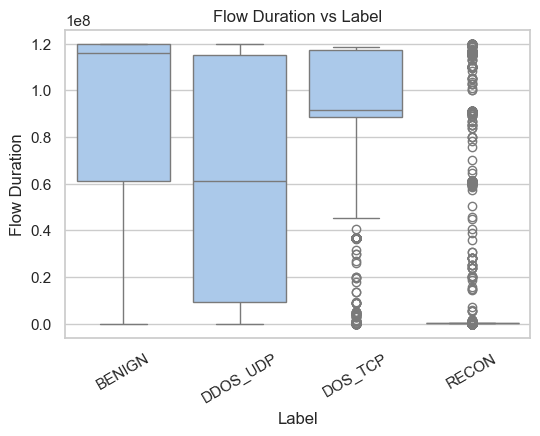

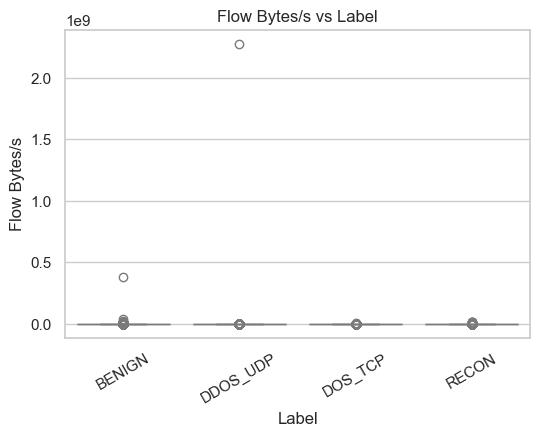

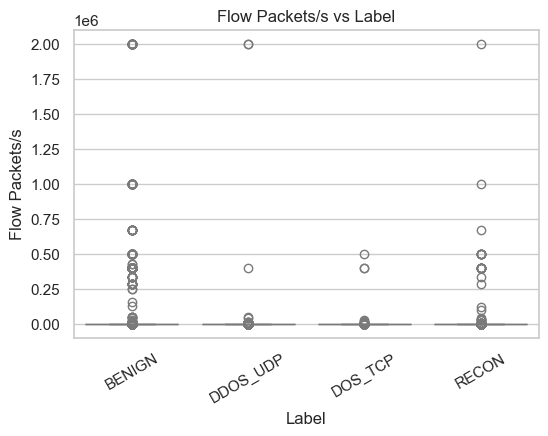

In [24]:
for f in features:
    plt.figure(figsize=(6,4))
    sns.boxplot(x="Label", y=f, data=df)
    plt.title(f"{f} vs Label")
    plt.xticks(rotation=30)
    plt.show()

### Interpreting the Core Feature Boxplots
These boxplots show how the central tendency and spread of the main traffic metrics differ by class. Features such as flow duration, packet count, and throughput are directly related to whether traffic behaves like normal communication, volumetric flooding, or repeated probing.

Key observations:
- Higher packet or byte activity suggests more aggressive resource consumption on the network.
- Wider spread and stronger outliers indicate unstable, bursty, or attack-driven behavior.
- Shorter and lighter flows are often associated with reconnaissance, while heavier rate-based features are more consistent with flooding attacks.


### Building a Correlation Matrix for Selected Features
This cell encodes the traffic label and computes correlations among the sampled features. Correlation analysis is useful in network traffic EDA because it shows which metrics rise or fall together during attacks.

Key observations:
- Correlated rate and packet features may capture shared flooding behavior.
- Weak relationships can indicate that different attack types stress the network in different ways.
- Including the label helps assess whether certain features align strongly with malicious traffic classes.


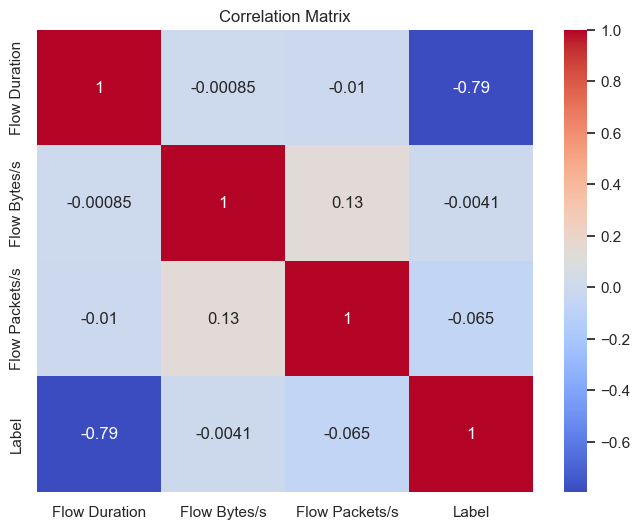

In [25]:
sample_df = df[features + ["Label"]].copy()

# convert label to numeric for correlation
sample_df["Label"] = sample_df["Label"].astype("category").cat.codes

plt.figure(figsize=(8,6))
sns.heatmap(sample_df.corr(), cmap="coolwarm", annot=True)
plt.title("Correlation Matrix")
plt.show()

### Interpreting the Correlation Matrix
The correlation heatmap helps identify which traffic features move together. In network terms, strong positive relationships between packet-based and byte-based metrics often indicate that flows are scaling in volume, while weaker relationships may reflect different attack mechanisms.

Key observations:
- Strong correlation between `Flow Bytes/s` and `Flow Packets/s` would be consistent with flood-style activity.
- Relationships involving the label suggest that some features are more discriminative for attack detection.
- Correlation patterns also help identify redundant features before downstream analysis.


### Plotting Feature Distributions with Histograms
This step visualizes the distributions of key features across traffic classes. Histograms are important in EDA because they show whether classes overlap or separate in terms of duration, throughput, and packet rate.

Key observations:
- Distribution shape matters as much as the average value.
- Multi-modal or skewed behavior can indicate multiple traffic regimes within an attack class.
- This helps connect numerical features to real network behaviors such as floods and scans.


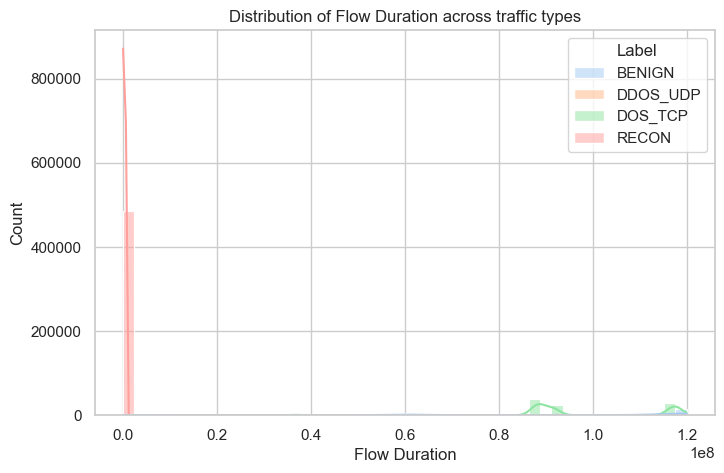

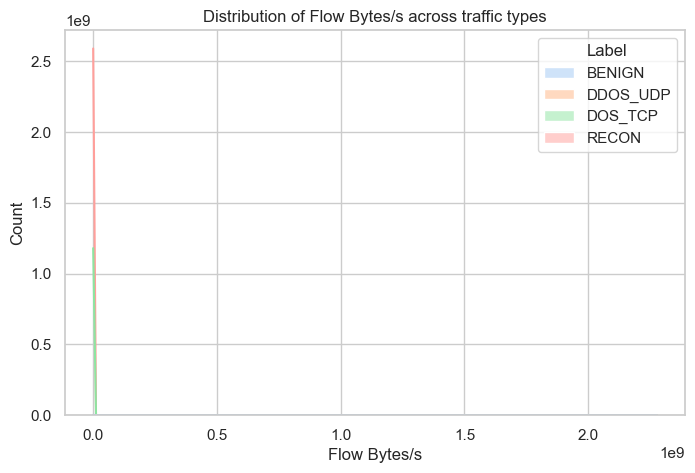

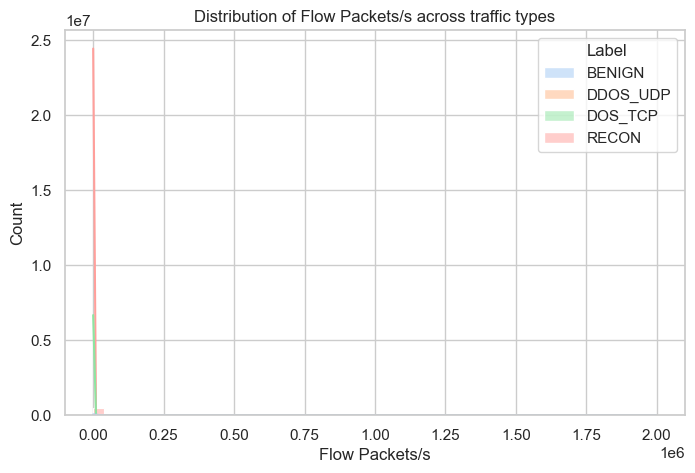

In [26]:
key_features = [
    "Flow Duration",
    "Flow Bytes/s",
    "Flow Packets/s"
]

key_features = [f for f in key_features if f in df.columns]

for f in key_features:
    plt.figure()
    sns.histplot(data=df, x=f, hue="Label", bins=50, kde=True)
    plt.title(f"Distribution of {f} across traffic types")
    plt.show()

### Interpreting the Histogram Distributions
The histograms show whether benign and malicious traffic occupy similar or distinct value ranges. In traffic analysis, separation in `Flow Duration`, `Flow Bytes/s`, or `Flow Packets/s` can reveal whether attacks are brief probes, sustained floods, or normal application sessions.

Key observations:
- A high-throughput tail is consistent with flooding behavior that pressures bandwidth or packet processing.
- Very short durations are more aligned with reconnaissance scanning than regular user activity.
- Overlap between classes indicates that some malicious traffic may mimic normal communication in individual features.


### Reinforcing Class Differences with Additional Boxplots
This cell provides another class-wise comparison of the main traffic features. Repeating the comparison in boxplot form makes it easier to evaluate spread, central tendency, and extreme behavior side by side.

Key observations:
- Boxplots complement histograms by summarizing the distribution compactly.
- They are effective for contrasting normal traffic with attack-driven outliers.
- This is helpful when assessing whether a feature is likely to separate classes clearly.


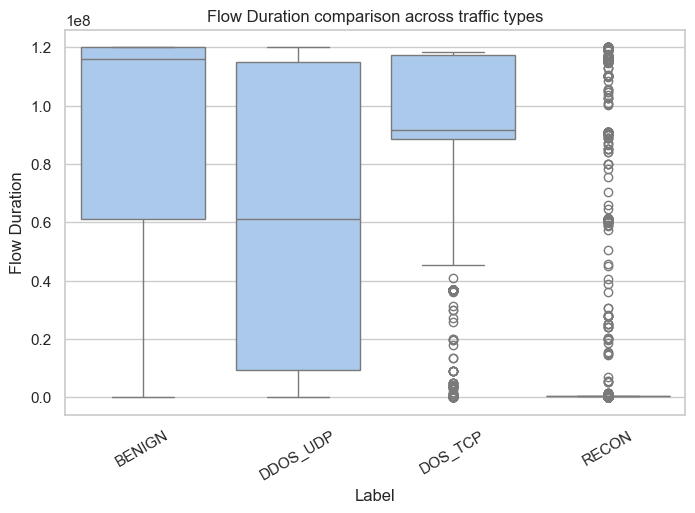

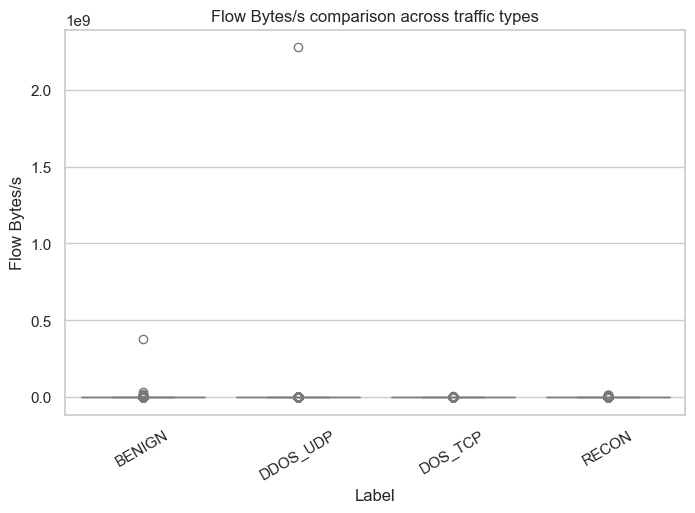

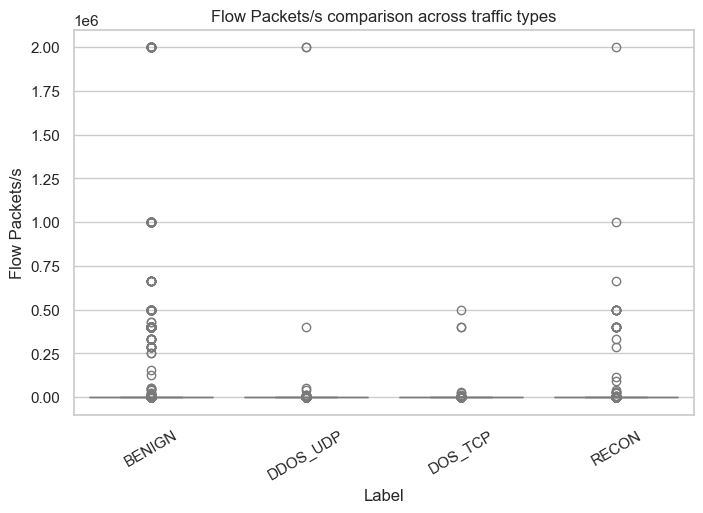

In [27]:
for f in key_features:
    plt.figure()
    sns.boxplot(x="Label", y=f, data=df)
    plt.xticks(rotation=30)
    plt.title(f"{f} comparison across traffic types")
    plt.show()

### Interpreting the Feature Comparison Boxplots
These boxplots make the class differences more compact and easier to compare. Looking at medians and interquartile ranges helps determine which features best separate benign traffic from UDP floods, TCP-based denial-of-service traffic, and reconnaissance scans.

Key observations:
- Distinct medians suggest a feature has discriminatory value for traffic classification.
- Broad upper ranges point to bursty attack behavior rather than stable application traffic.
- Features with strong class separation are especially valuable for later detection workflows.


### Analyzing SYN Flag Activity
This cell focuses on `SYN Flag Count`, a transport-layer feature closely tied to TCP setup behavior. SYN activity is particularly important in traffic security analysis because it can expose scan traffic or TCP-oriented denial-of-service behavior.

Key observations:
- SYN-heavy patterns can indicate connection probing or handshake abuse.
- Benign traffic also uses SYN packets, but usually within balanced sessions.
- Comparing SYN counts by class helps distinguish normal connection establishment from suspicious behavior.


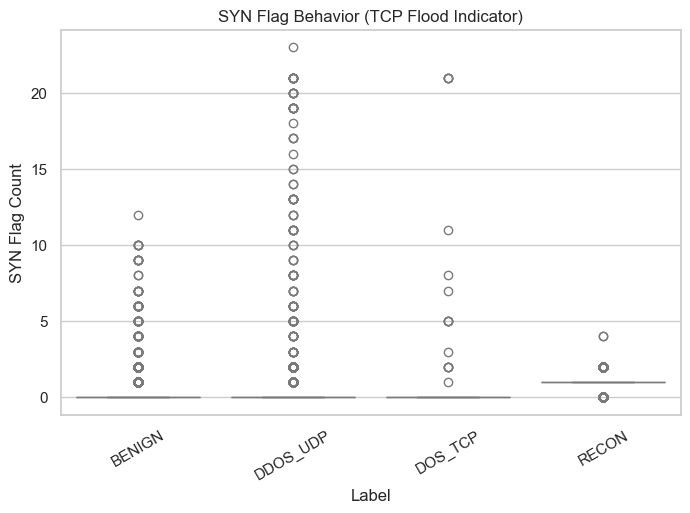

In [28]:
if "SYN Flag Count" in df.columns:
    sns.boxplot(x="Label", y="SYN Flag Count", data=df)
    plt.title("SYN Flag Behavior (TCP Flood Indicator)")
    plt.xticks(rotation=30)
    plt.show()

### Interpreting SYN Flag Behavior
The SYN flag plot provides transport-level context for the observed traffic classes. Higher or more consistent SYN activity can indicate connection initiation patterns associated with TCP scans or SYN-oriented abuse, whereas benign traffic usually mixes SYN with subsequent bidirectional exchange.

Key observations:
- A consistent low-but-present SYN pattern can reflect systematic reconnaissance scanning.
- Unusual SYN behavior is important because it points to control-plane stress rather than payload-heavy traffic.
- This feature complements throughput metrics by capturing how attacks interact with the TCP handshake process.


### Applying PCA for Low-Dimensional Visualization
This step uses Principal Component Analysis (PCA) to compress many numeric traffic features into two components. In simple terms, PCA finds the main linear directions of variation so we can see whether traffic classes separate in a 2D space.

Key observations:
- PCA is a linear dimensionality reduction technique.
- It helps summarize many flow features without inspecting each one individually.
- Visible class separation suggests that attacks differ along broad linear combinations of network features.


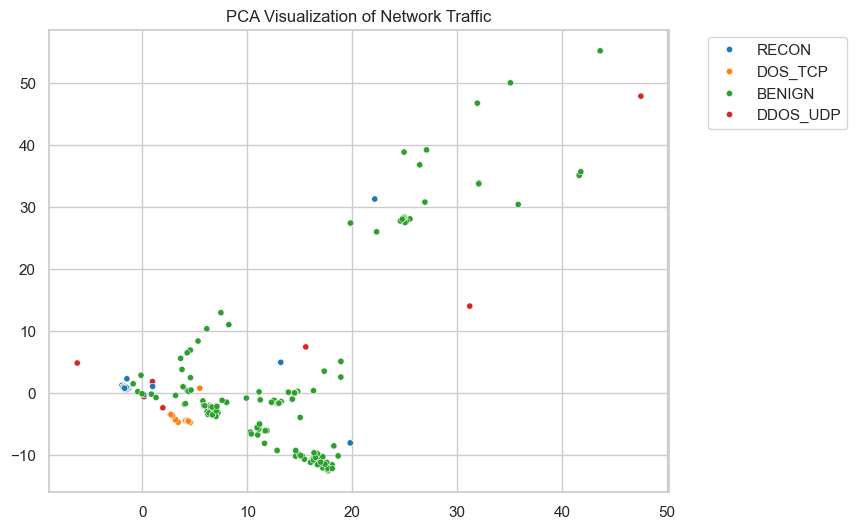

In [29]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# keep only numeric columns
df_pca = df.select_dtypes(include=["number"]).dropna()

# sample for speed
df_sample = df_pca.sample(n=5000, random_state=42)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_sample)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# map labels
labels = df.loc[df_sample.index, "Label"]

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=labels, palette="tab10", s=20)
plt.title("PCA Visualization of Network Traffic")
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.show()

### Interpreting the PCA Projection
The PCA scatterplot shows whether the traffic classes separate under a linear transformation of the numeric features. If clusters appear partially separated, that suggests some attack types differ along broad linear trends such as duration, packet count, and rate, while overlapping groups indicate limited linear separability.

Key observations:
- Clear separation suggests the classes differ in major aggregate flow behaviors.
- Overlap implies that some attacks resemble benign traffic under simple linear views.
- PCA is useful as a first summary, but it may miss more complex non-linear structure in network traffic.


### Applying t-SNE for Non-Linear Traffic Structure
This cell uses t-SNE to project high-dimensional traffic data into two dimensions. In simple terms, t-SNE is useful for showing local structure and cluster patterns when class separation depends on non-linear feature interactions.

Key observations:
- t-SNE emphasizes local neighborhoods rather than global linear variance.
- It is often better than PCA at revealing compact attack clusters.
- This makes it useful for seeing whether malicious flows form distinct behavioral groups.


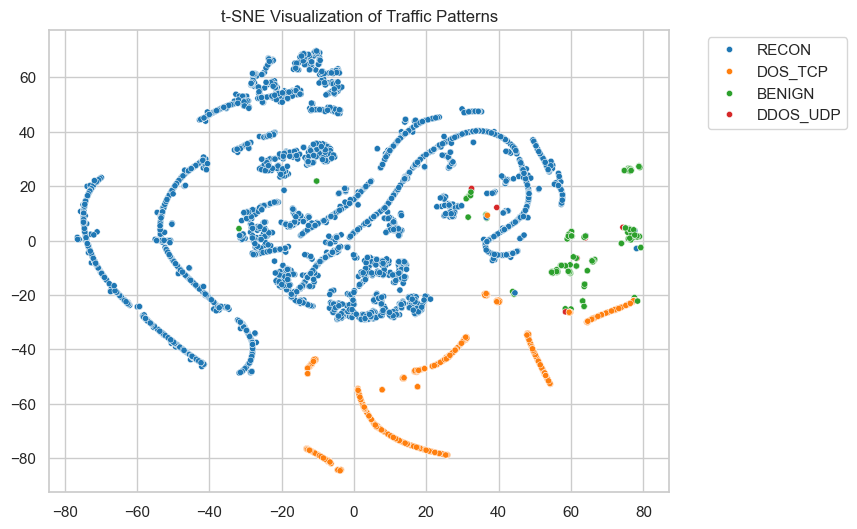

In [30]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=30, random_state=42)

X_tsne = tsne.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], hue=labels, palette="tab10", s=20)
plt.title("t-SNE Visualization of Traffic Patterns")
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.show()

### Interpreting the t-SNE Projection
The t-SNE plot is designed to reveal non-linear clustering that PCA may compress. Stronger separation here would suggest that benign, flood, and reconnaissance traffic differ through more complex combinations of flow features rather than a single linear boundary.

Key observations:
- Distinct clusters indicate non-linear separability between traffic classes.
- Compact reconnaissance clusters would align with repetitive probe behavior across many similar short flows.
- More diffuse flood clusters suggest that denial-of-service traffic can vary in intensity while remaining malicious.


### Examining Correlation Among Key Traffic Features
This final heatmap focuses specifically on the selected high-value traffic features. A targeted correlation view helps clarify whether duration, byte rate, and packet rate reinforce the same network behavior or describe different attack effects.

Key observations:
- Strong correlation suggests overlapping behavioral information.
- Weak or moderate correlation implies that each feature contributes distinct insight.
- This is useful when deciding which metrics best characterize flooding or reconnaissance traffic.


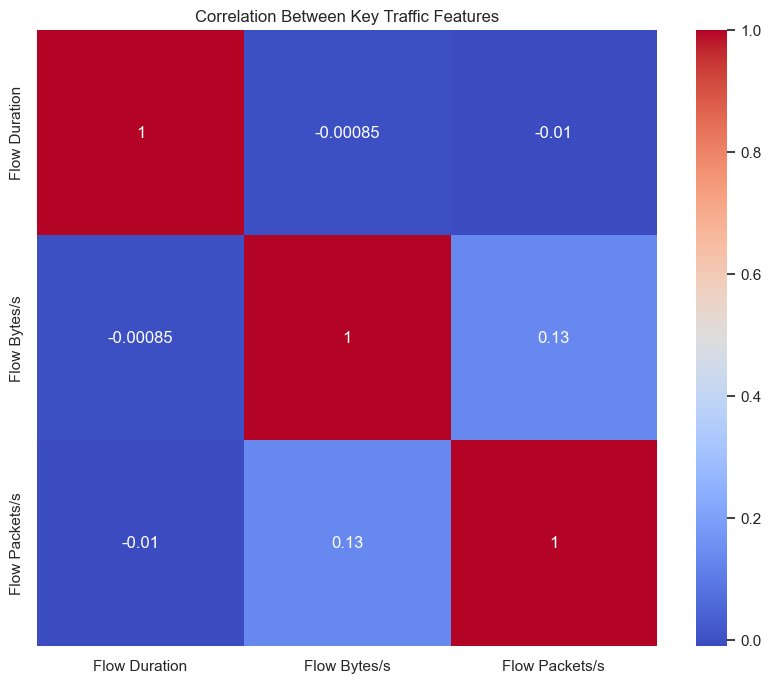

In [31]:
plt.figure(figsize=(10,8))
sns.heatmap(df[key_features].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Between Key Traffic Features")
plt.show()

### Interpreting the Key-Feature Heatmap
This focused heatmap summarizes how the most important traffic metrics relate to one another. In networking terms, it helps clarify whether duration, byte rate, and packet rate are reinforcing the same behavioral story or describing different attack effects.

Key observations:
- Strong positive correlation between rate features is consistent with traffic bursts and flooding pressure.
- Weak correlation with duration can indicate that short probe traffic behaves differently from sustained flows.
- These relationships help explain why multiple features are needed to distinguish `BENIGN`, `DDOS_UDP`, `DOS_TCP`, and `RECON` accurately.


### Final Summary
The dataset exhibits strong class-specific behavioral patterns. Attack traffic, particularly DDoS, is characterized by extremely high packet rates and byte transfer rates, resulting in heavy-tailed distributions with significant outliers. Reconnaissance traffic shows shorter flow durations and repeated probing behavior.

Key observations:
- Correlation analysis and feature distributions indicate that traffic volume and timing-based features are critical indicators of malicious activity.
- Dimensionality reduction using PCA shows partial class separation, while t-SNE reveals more distinct clustering.
- These results suggest that the dataset contains non-linear structures that can be effectively exploited for classification tasks.
